# Analisis Basado en Eventos y Test A/A/B

### Descripcion del Proyecto

Trabajas en una empresa emergente que vende productos alimenticios. Debes investigar el comportamiento del usuario para la aplicación de la empresa.

Primero, estudia el embudo de ventas. Descubre cómo los usuarios llegan a la etapa de compra. ¿Cuántos usuarios realmente llegan a esta etapa? ¿Cuántos se atascan en etapas anteriores? ¿Qué etapas en particular?

Luego, observa los resultados de un test A/A/B (sigue leyendo para obtener más información sobre los test A/A/B). Al equipo de diseño le gustaría cambiar las fuentes de toda la aplicación, pero la gerencia teme que los usuarios piensen que el nuevo diseño es intimidante. Por ello, deciden tomar una decisión basada en los resultados de un test A/A/B.

Los usuarios se dividen en tres grupos: dos grupos de control obtienen las fuentes antiguas y un grupo de prueba obtiene las nuevas. Descubre qué conjunto de fuentes produce mejores resultados.

Crear dos grupos A tiene ciertas ventajas. Podemos establecer el principio de que solo confiaremos en la exactitud de nuestras pruebas cuando los dos grupos de control sean similares. Si hay diferencias significativas entre los grupos A, esto puede ayudarnos a descubrir factores que pueden estar distorsionando los resultados. La comparación de grupos de control también nos dice cuánto tiempo y datos necesitaremos cuando realicemos más tests.

Utilizarás el mismo dataset para el análisis general y para el análisis A/A/B. En proyectos reales, los experimentos se llevan a cabo constantemente. El equipo de análisis estudia la calidad de una aplicación utilizando datos generales, sin prestar atención a si los usuarios participan en experimentos.

### Descripción de los datos

Cada entrada de registro es una acción de usuario o un evento.

* `EventName`: nombre del evento.
* `DeviceIDHash`: identificador de usuario unívoco.
* `EventTimestamp`: hora del evento.
* `ExpId`: número de experimento. 246 y 247 son los grupos de control, y 248 es el grupo de prueba.

## Paso 1. Abrir el archivo de datos y leer la información general

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats as st
import plotly.graph_objects as go

In [2]:
# Cargar y leer dataset
logs_data = pd.read_csv('logs_exp_us.csv', sep='\t')

In [3]:
# Informacion del dataset
logs_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [4]:
# Imprimir muestra del dataset
logs_data.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [5]:
# Revisar duplicados
print(f"Cantidad de filas duplicadas: {logs_data.duplicated().sum()}")

Cantidad de filas duplicadas: 413


In [6]:
# Eliminar duplicados
logs_data.drop_duplicates(inplace=True)

### === Observaciones iniciales ===

El dataset `logs_exp_us.csv` contiene 4 columnas con informacion sobre los eventos y actividades de usuarios en la app, id de dispositivo o usuario, registro de tiempo (fecha y hora) de cada evento y un id del grupo de experimento. No hay valores ausentes pero encontramos 413 duplicados que eliminamos de una. Quiza podamos estandarizar los nombres de columnas, cambiar el formato y tipo de dato de la columna `EventTimestamp`.

## Paso 2. Preparar los datos para el análisis

Vamos a estandarizar y renombrar nombres de columnas. Ademas vamos a convertir la columna `EventTimestamp` a tipo datetime y crear una columna separada para mostrar unicamente la fecha.

In [7]:
# renombrar columnas
logs_data.columns = ['event_name', 'user_id', 'event_ts', 'group_id']

In [8]:
# Cambiar tipo de dato a datetime
logs_data['event_ts'] = pd.to_datetime(logs_data['event_ts'], unit='s')

In [9]:
# Crear columna separada para fecha
logs_data['date'] = logs_data['event_ts'].dt.date

In [10]:
# Imprimir muestra
logs_data.head()

,event_name,user_id,event_ts,group_id,date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


## Paso 3. Estudiar y comprobar los datos

### 3.1 ¿Cuántos eventos hay en los registros?

Vamos a calcular cual es el numero de eventos totales en el dataset y cuales son estos eventos.

In [11]:
print("Eventos: ", logs_data['event_name'].unique())
print("\nNumero de Eventos: ", logs_data['event_name'].nunique())

Eventos:  ['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']

Numero de Eventos:  5


### 3.2 ¿Cuántos usuarios hay en los registros?

Ahora vamos a extraer cual es el numero total de usuarios unicos en el dataset. De la columna 'user_id' podemos usar el metodo nunique() para obtener el numero exacto de usuarios unicos.

In [12]:
print("Cantidad de usuarios unicos en los registros: ", logs_data['user_id'].nunique())

Cantidad de usuarios unicos en los registros:  7551


### 3.3 ¿Cuál es el promedio de eventos por usuario?

El promedio de eventos por usuario lo podemos obtener usando groupby(), es decir, agrupar por usuarios y luego contar el numero de eventos por usuario. Tambien podriamos calcular directamente el promedio de eventos, pero lo haremos por separado.

In [13]:
# Agrupar por usuario y contar eventos por usuario
events_by_user = logs_data.groupby('user_id')['event_name'].count().reset_index(name='event_count')

In [14]:
# Imprimir eventos por usuario
print("Eventos por Usuario (Primeros 10): \n")
events_by_user.head(10)

Eventos por Usuario (Primeros 10): 



,user_id,event_count
0,6888746892508752,1
1,6909561520679493,5
2,6922444491712477,47
3,7435777799948366,6
4,7702139951469979,137
5,8486814028069281,10
6,8740973466195562,9
7,9841258664663090,29
8,12692216027168046,10
9,15708180189885246,126


In [15]:
# Promedio de eventos por usuario
print("Promedio de Eventos por Usuario: ", events_by_user['event_count'].mean())

Promedio de Eventos por Usuario:  32.27559263673685


### 3.4 ¿Qué periodo de tiempo cubren los datos?

Para este paso vamos a extraer la fecha máxima y mínima y despues vamos a trazar un histograma por fecha y hora para observar la distribucion de los eventos a lo largo del periodo de los datos y determinar si podemos tomar los datos de todo el periodo o es mejor tomarlos a partir de una fecha especifica.

In [16]:
# Fecha minima y maxima
print("Fecha Inicial: ", logs_data['date'].min())
print("Fecha Final: ", logs_data['date'].max())

Fecha Inicial:  2019-07-25
Fecha Final:  2019-08-07


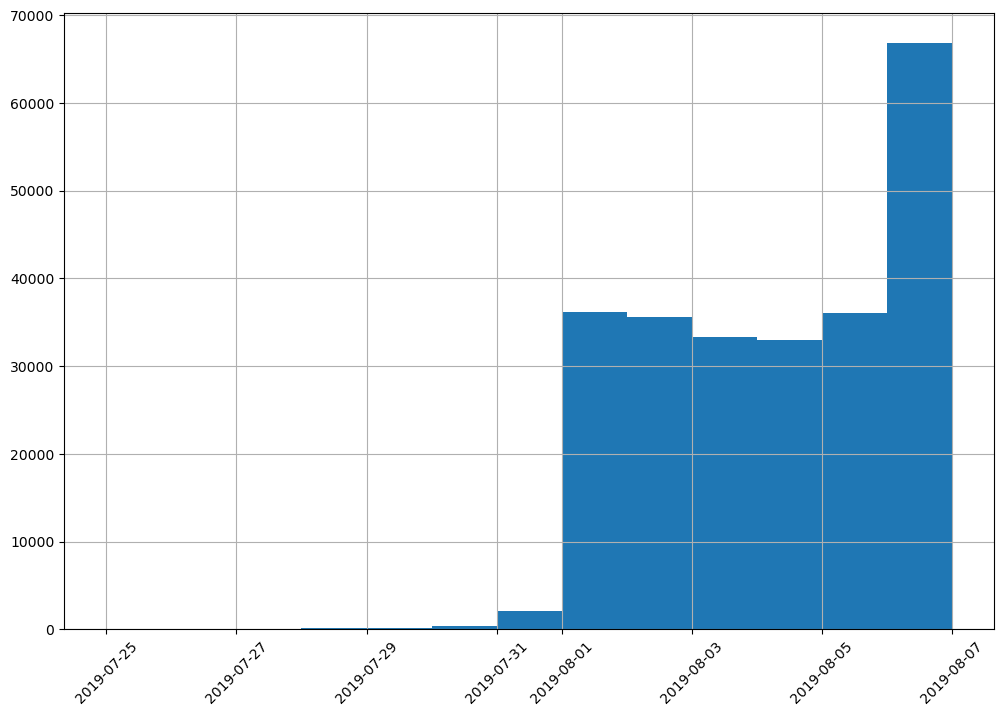

In [17]:
# Histograma por fecha y hora
plt.figure(figsize=(12, 8))
logs_data['date'].hist(bins=13)
plt.xticks(rotation=45)
plt.show()

### === Observaciones - ¿Qué periodo representan realmente los datos? ===

A partir de la informacion que nos muestra el histograma, los datos probablemente estan incompletos antes del primero de agosto, ya que son muy escasos y no nos sirven. Ademas podrian causan anomalias e irregularidades en los calculos. Por lo anterior seria mas razonable tomar en cuenta unicamente los datos despues del 2019-08-01.

### 3.5 Filtrar datos a partir del 2019-08-01

Vamos a hacer un slice de los datos. Solo vamos tomar los datos a partir de 2019-08-01, ya los datos anteriores a esa fecha pueden alterar mucho los resultados de las pruebas. Necesitamos datos lo mas limpios y consistentes posibles para sacar mejores resultados y conclusiones.

In [18]:
# Filtrar datos a partir de 1ro de agosto de 2019
logs_data = logs_data[logs_data['event_ts'] > '2019-08-01']

In [19]:
# Comprobar fecha minima
print("Fecha minima: \n", logs_data['date'].min())

Fecha minima: 
 2019-08-01


In [20]:
# Calcular numero de eventos por grupo de experimento
print("Numero de Eventos por grupo: \n")
logs_data['group_id'].value_counts()

Numero de Eventos por grupo: 



group_id
248    84563
246    79302
247    77022
Name: count, dtype: int64

In [21]:
# Calcular numero de usuarios unicos despues de filtrar datos
print("Numero de usuarios unicos: ", logs_data['user_id'].nunique())

Numero de usuarios unicos:  7534


### === Observaciones ===

Despues de filtrar los datos a partir del 2019-08-01, comprobamos cuantos eventos hay registrados por grupo y cuantos usuarios unicos restantes hay. Antes del filtro habia 7551 usuarios y despues 7534, por lo que la cantidad se mantiene casi igual. No perdimos muchos datos al hacer el filtro y ganamos una mayor consistencia en los datos.

## Paso 4. Estudiar el embudo de eventos

Una vez hemos asegurado la limpieza, consistencia y confiabilidad en los datos, vamos a proceder al analisis de embudo de eventos.

### 4.1 Qué eventos hay en los registros y su frecuencia de suceso

Vamos a calcular el numero de eventos que hay y su frecuencia. Para este caso podemos utilizar value_counts() usar reset_index() para crear un tabla o dataframe y ordenar de forma descendente.

In [22]:
# Ordenar eventos por frecuencia y ordenar descendente
event_count = logs_data['event_name'].value_counts().reset_index(name='event_count').sort_values('event_count', ascending=False)

# Renombrar columnas
event_count.columns = ['event_name', 'event_count']

In [23]:
# Imprimir resultado
event_count

,event_name,event_count
0,MainScreenAppear,117328
1,OffersScreenAppear,46333
2,CartScreenAppear,42303
3,PaymentScreenSuccessful,33918
4,Tutorial,1005


### === Observaciones ===

El evento que mas ocurre es la pagina principal, lo cual es normal ya que es lo primero que ven los usuarios registrados al acceder a la app. En segundo lugar esta la pagina de ofertas. En tercer lugar esta la pagina de carrito. En cuarto lugar esta la pagina de pago exitoso y finalmente la pagina de tutorial.

### 4.2 Calcular la cantidad de usuarios que realizaron cada una de estas acciones

In [24]:
# Agrupar por evento y calcular el numero de usuarios unicos por evento
event_user_count = logs_data.groupby('event_name')['user_id'].nunique().reset_index()

# Renombrar columnas
event_user_count.columns = ['event_name', 'user_count']

In [25]:
# Ordenar descendente y mostrar resultados
event_user_count = event_user_count.sort_values('user_count', ascending=False)
event_user_count

,event_name,user_count
1,MainScreenAppear,7419
2,OffersScreenAppear,4593
0,CartScreenAppear,3734
3,PaymentScreenSuccessful,3539
4,Tutorial,840


### 4.3 Calcular la proporción de usuarios que realizaron la acción al menos una vez

In [26]:
# Agregar la proporcion de usuarios por evento del embudo
event_user_count['proportion'] = event_user_count['user_count'] / logs_data['user_id'].nunique()

In [27]:
# Imprimir resultados
event_user_count

,event_name,user_count,proportion
1,MainScreenAppear,7419,0.984736
2,OffersScreenAppear,4593,0.609636
0,CartScreenAppear,3734,0.495620
3,PaymentScreenSuccessful,3539,0.469737
4,Tutorial,840,0.111495


### === Observaciones ===

El 98.4% de usuarios entraron a ver la pagina principal. Luego, solo el 60.9% del total de usuarios unicos fueron a ver la pagina de ofertas. El 49.5% accedio a la pagina de carrito y el 46.9% llego hasta la pagina de pago exitoso. Solo un 11% del total de usuarios vieron la pagina de tutorial.

### 4.4 ¿En qué orden ocurrieron las acciones? ¿Todas son parte de una sola secuencia?

De acuerdo a los resultados anteriores podemos deducir que el orden de eventos es como sigue:

1. Main Screen Appear
2. Offers Screen Appear
3. Cart Screen Appear
4. Payment Screen Successful

El tutorial realmente no parece formar parte integral del orden de eventos, muy pocos usuarios realizan el tutorial, por lo que podriamos excluirlo.

### 4.5 Utilizar el embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente

De la libreria de plotly podemos usar el modulo de graph_objects para crear una grafico de embudo y poder observar de forma visual como se ve la secuencia de eventos como un embudo.

In [28]:
# Crear grafico de embudo
embudo = go.Figure(go.Funnel(y=event_user_count['event_name'] , x=event_user_count['user_count']))
embudo.update_layout(title='Proporcion de Usuarios por Evento del Embudo')
embudo.show()

### === Observaciones - ¿En qué etapa se pierden más usuarios? ===

De acuerdo a los resultados del embudo de eventos, la etapa en la que se pierden mas usuarios es de Main Screen a Offers Screen. Solo 61.9% de la etapa anterior continuan hacia la pagina de Offers. Cerca de un 40% de usuarios no pasan de la Main Screen a la etapa siguiente.

* MainScreenAppear: 7419 usuarios --> 100%
* OffersScreenAppear: 4593 usuarios --> 61.9% --> 61.9% de la cantidad de arriba
* CartScreenAppear: 3734 usuarios --> 50.3% --> 81.3 de la cantidad de arriba
* PaymentScreenSuccessful: 3539 usuarios --> 47.7% --> 94.8% de la cantidad de arriba
* Tutorial: 840 usuarios --> 11.3% --> 23.7% de la cantidad anterior

### === Observaciones - ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago? ===

A partir de los resultados del embudo podemos observar que solo el 46.9% del total de usuarios llega hasta la pagina de pago, esto representa solo  el 47.7% de los usuarios que entraron a ver la pagina principal, es decir, menos de la mitad de usuarios registrados.

## Paso 5. Estudiar los resultados del experimento

Vamos a proceder a analizar los grupos del Test A/A/B

### 5.1 ¿Cuántos usuarios hay en cada grupo?

In [29]:
# Agrupar por grupos y calcular los usuarios unicos por grupo
print("Cantidad de usuarios por grupo: \n")
logs_data.groupby('group_id')['user_id'].nunique().reset_index(name='num_users')

Cantidad de usuarios por grupo: 



,group_id,num_users
0,246,2484
1,247,2513
2,248,2537


### === Observaciones ===

Los tres grupos tienen una cantidad muy similar de usuarios. Los grupos 246 y 247 son los dos grupos de control. El grupo 248 seria nuestro grupo B, el grupo experimental.

### 5.2 Verificar si hay una diferencia estadísticamente significativa entre las muestras 246 y 247

Vamos a comprobar si hay un diferencia estadisticamente significativa entre los grupos de control. Para esto podemos realizar unas pruebas comparando los eventos.

* Selecciona el evento más popular.
* En cada uno de los grupos de control, encuentra la cantidad de usuarios que realizaron esta acción.
* Encuentra su proporción.
* Comprueba si la diferencia entre los grupos es estadísticamente significativa.
* Repite el procedimiento para todos los demás eventos.
* ¿Puedes confirmar que los grupos se dividieron correctamente?

In [30]:
# Agrupar por grupos y eventos. Conteo de usuarios por grupo y evento
group_event = logs_data.groupby(['group_id', 'event_name'])['user_id'].nunique().reset_index(name='num_users')
group_event

,group_id,event_name,num_users
0,246,CartScreenAppear,1266
1,246,MainScreenAppear,2450
2,246,OffersScreenAppear,1542
3,246,PaymentScreenSuccessful,1200
4,246,Tutorial,278
5,247,CartScreenAppear,1238
6,247,MainScreenAppear,2476
7,247,OffersScreenAppear,1520
8,247,PaymentScreenSuccessful,1158
9,247,Tutorial,283


In [31]:
# El evento más popular: MainScreenAppear
print("Evento más popular:", event_count.iloc[0]['event_name'])
print("Frecuencia:", event_count.iloc[0]['event_count'])

Evento más popular: MainScreenAppear
Frecuencia: 117328


### Nota

Para este paso, vamos a crear una funcion que realice la prueba Z de proporciones, comparando primero ambos grupos de control y verificar si no hay diferencias estadisticamente significativas. Si no las hay podremos concluir que los datos de estos grupos son confiables y proceder a compara los resultados con el grupo experimental, el grupo que se le dio la app con las fuentes modificadas.

In [32]:
# Importar prueba de proporciones Z Test
from statsmodels.stats.proportion import proportions_ztest

def test_proportions_between_groups(event_name, group1_id=246, group2_id=247):
    """
    Función para comparar proporciones entre dos grupos para un evento específico
    """
    # Filtrar datos para los grupos de control
    group1_data = logs_data[logs_data['group_id'] == group1_id]
    group2_data = logs_data[logs_data['group_id'] == group2_id]
    
    # Calcular usuarios únicos totales por grupo
    total_users_group1 = group1_data['user_id'].nunique()
    total_users_group2 = group2_data['user_id'].nunique()
    
    # Calcular usuarios que realizaron el evento específico
    users_event_group1 = group1_data[group1_data['event_name'] == event_name]['user_id'].nunique()
    users_event_group2 = group2_data[group2_data['event_name'] == event_name]['user_id'].nunique()
    
    # Calcular proporciones
    prop_group1 = users_event_group1 / total_users_group1
    prop_group2 = users_event_group2 / total_users_group2
    
    # Realizar prueba Z de proporciones
    successes = [users_event_group1, users_event_group2]
    totals = [total_users_group1, total_users_group2]
    
    z_stat, p_value = proportions_ztest(successes, totals)
    
    # Mostrar resultados
    print(f"\n=== Evento: {event_name} ===")
    print(f"Grupo 246: {users_event_group1}/{total_users_group1} usuarios ({prop_group1:.4f})")
    print(f"Grupo 247: {users_event_group2}/{total_users_group2} usuarios ({prop_group2:.4f})")
    print(f"Diferencia en proporciones: {abs(prop_group1 - prop_group2):.4f}")
    print(f"Estadístico Z: {z_stat:.4f}")
    print(f"Valor p: {p_value:.4f}")
    
    # Interpretar resultado
    alpha = 0.05
    if p_value < alpha:
        print("❌ DIFERENCIA SIGNIFICATIVA - Los grupos NO son similares")
    else:
        print("✅ NO hay diferencia significativa - Los grupos son similares")
    
    return {
        'event': event_name,
        'prop_246': prop_group1,
        'prop_247': prop_group2,
        'z_stat': z_stat,
        'p_value': p_value,
        'significant': p_value < alpha
    }

In [33]:
# Ejecutar funcion para comparar grupos de control - Evento: 'MainScreenAppear'
test_proportions_between_groups('MainScreenAppear')


=== Evento: MainScreenAppear ===
Grupo 246: 2450/2484 usuarios (0.9863)
Grupo 247: 2476/2513 usuarios (0.9853)
Diferencia en proporciones: 0.0010
Estadístico Z: 0.3093
Valor p: 0.7571
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'MainScreenAppear',
 'prop_246': 0.9863123993558777,
 'prop_247': 0.9852765618782332,
 'z_stat': np.float64(0.3093441851418436),
 'p_value': np.float64(0.7570597232046099),
 'significant': np.False_}

In [34]:
# Ejecutar funcion para comparar grupos de control - Evento: 'OffersScreenAppear'
test_proportions_between_groups('OffersScreenAppear')


=== Evento: OffersScreenAppear ===
Grupo 246: 1542/2484 usuarios (0.6208)
Grupo 247: 1520/2513 usuarios (0.6049)
Diferencia en proporciones: 0.0159
Estadístico Z: 1.1550
Valor p: 0.2481
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'OffersScreenAppear',
 'prop_246': 0.6207729468599034,
 'prop_247': 0.6048547552725826,
 'z_stat': np.float64(1.154987713610383),
 'p_value': np.float64(0.2480954578522181),
 'significant': np.False_}

In [35]:
# Ejecutar funcion para comparar grupos de control - Evento: 'CartScreenAppear'
test_proportions_between_groups('CartScreenAppear')


=== Evento: CartScreenAppear ===
Grupo 246: 1266/2484 usuarios (0.5097)
Grupo 247: 1238/2513 usuarios (0.4926)
Diferencia en proporciones: 0.0170
Estadístico Z: 1.2034
Valor p: 0.2288
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'CartScreenAppear',
 'prop_246': 0.5096618357487923,
 'prop_247': 0.4926382809391166,
 'z_stat': np.float64(1.203368576486285),
 'p_value': np.float64(0.22883372237997213),
 'significant': np.False_}

In [36]:
# Ejecutar funcion para comparar grupos de control - Evento: 'PaymentScreenSuccessful'
test_proportions_between_groups('PaymentScreenSuccessful')


=== Evento: PaymentScreenSuccessful ===
Grupo 246: 1200/2484 usuarios (0.4831)
Grupo 247: 1158/2513 usuarios (0.4608)
Diferencia en proporciones: 0.0223
Estadístico Z: 1.5780
Valor p: 0.1146
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'PaymentScreenSuccessful',
 'prop_246': 0.4830917874396135,
 'prop_247': 0.46080382013529647,
 'z_stat': np.float64(1.5779948491596598),
 'p_value': np.float64(0.11456679313141847),
 'significant': np.False_}

### === Observaciones - Nivel de significacia estadistica alpha = 0.05 ===

Las pruebas para todas las comparaciones nos dicen que no hay diferencias significativas entre los grupos de control. Es decir que podemos asegurar que los grupos de control fueron divididos correctamente y confiar en que los datos son validos.

### === Observaciones - Nivel de significacia estadistica alpha = 0.01 ===

Volvimos a correr las pruebas pero esta vez indicando el nivel de significacia alpha en 0.01. Los resultados fueron muy similares y nuevamente comprobamos la confiabilidad de los datos de los grupos de control.

### 5.3 Comparar los resultados con los de cada uno de los grupos de control para cada evento de forma aislada

Para comparar los grupos de control con el grupo experimental vamos a crear un funcion muy similar como el paso anterior. Luego vamos a crear un bucle for para que itere cada uno de los grupos de control y cada uno de los eventos contra el grupo experimental.

#### Funcion para comparar grupos de control y grupo experimental

In [37]:
def test_proportions_between_groups_2(event_name, group1_id=248, group2_id=247):
    """
    Función para comparar proporciones entre dos grupos para un evento específico
    """
    # Filtrar datos para los grupos de control
    group1_data = logs_data[logs_data['group_id'] == group1_id]
    group2_data = logs_data[logs_data['group_id'] == group2_id]
    
    # Calcular usuarios únicos totales por grupo
    total_users_group1 = group1_data['user_id'].nunique()
    total_users_group2 = group2_data['user_id'].nunique()
    
    # Calcular usuarios que realizaron el evento específico
    users_event_group1 = group1_data[group1_data['event_name'] == event_name]['user_id'].nunique()
    users_event_group2 = group2_data[group2_data['event_name'] == event_name]['user_id'].nunique()
    
    # Calcular proporciones
    prop_group1 = users_event_group1 / total_users_group1
    prop_group2 = users_event_group2 / total_users_group2
    
    # Realizar prueba Z de proporciones
    successes = [users_event_group1, users_event_group2]
    totals = [total_users_group1, total_users_group2]
    
    z_stat, p_value = proportions_ztest(successes, totals)
    
    # Mostrar resultados
    print(f"\n=== Evento: {event_name} ===")
    print(f"Grupo Experimental: {users_event_group1}/{total_users_group1} usuarios ({prop_group1:.4f})")
    print(f"Grupo de Control: {users_event_group2}/{total_users_group2} usuarios ({prop_group2:.4f})")
    print(f"Diferencia en proporciones: {abs(prop_group1 - prop_group2):.4f}")
    print(f"Estadístico Z: {z_stat:.4f}")
    print(f"Valor p: {p_value:.4f}")
    
    # Interpretar resultado
    alpha = 0.01
    if p_value < alpha:
        print("❌ DIFERENCIA SIGNIFICATIVA - Los grupos NO son similares")
    else:
        print("✅ NO hay diferencia significativa - Los grupos son similares")
    
    return {
        'event': event_name,
        'prop_248': prop_group1,
        'prop_247': prop_group2,
        'z_stat': z_stat,
        'p_value': p_value,
        'significant': p_value < alpha
    }

#### Bucle for para iterar grupos de control y eventos

In [38]:
# Lista de todos los eventos para iterar
eventos = logs_data['event_name'].unique()
print("Eventos a analizar:", eventos)

# Resultados para almacenar comparaciones
resultados_248_vs_246 = []
resultados_248_vs_247 = []

print("\n" + "="*60)
print("COMPARACIÓN: GRUPO EXPERIMENTAL (248) vs GRUPO CONTROL A (246)")
print("="*60)

for evento in eventos:
    resultado = test_proportions_between_groups_2(evento, group1_id=248, group2_id=246)
    resultados_248_vs_246.append(resultado)

print("\n" + "="*60)
print("COMPARACIÓN: GRUPO EXPERIMENTAL (248) vs GRUPO CONTROL B (247)")
print("="*60)

for evento in eventos:
    resultado = test_proportions_between_groups_2(evento, group1_id=248, group2_id=247)
    resultados_248_vs_247.append(resultado)

Eventos a analizar: ['Tutorial' 'MainScreenAppear' 'OffersScreenAppear' 'CartScreenAppear'
 'PaymentScreenSuccessful']

COMPARACIÓN: GRUPO EXPERIMENTAL (248) vs GRUPO CONTROL A (246)

=== Evento: Tutorial ===
Grupo Experimental: 279/2537 usuarios (0.1100)
Grupo de Control: 278/2484 usuarios (0.1119)
Diferencia en proporciones: 0.0019
Estadístico Z: -0.2193
Valor p: 0.8264
✅ NO hay diferencia significativa - Los grupos son similares

=== Evento: MainScreenAppear ===
Grupo Experimental: 2493/2537 usuarios (0.9827)
Grupo de Control: 2450/2484 usuarios (0.9863)
Diferencia en proporciones: 0.0037
Estadístico Z: -1.0473
Valor p: 0.2950
✅ NO hay diferencia significativa - Los grupos son similares

=== Evento: OffersScreenAppear ===
Grupo Experimental: 1531/2537 usuarios (0.6035)
Grupo de Control: 1542/2484 usuarios (0.6208)
Diferencia en proporciones: 0.0173
Estadístico Z: -1.2581
Valor p: 0.2084
✅ NO hay diferencia significativa - Los grupos son similares

=== Evento: CartScreenAppear ===
Gr

### === Observaciones ===

Realizamos las pruebas con dos diferentes valores de significancia alpha, 0.05 y 0.01. En ambos, los resultados fueron similares. Parece que modificar las fuentes no ha tenido ningun efecto en el comportamiento de los usuarios al usar la app. Los resultados de los grupos de control y el grupo experimental se muestran muy similares y segun la prueba realizada podemos concluir que no ha causado ninguna diferencia el modificar las fuentes de la app.

### Comparar los resultados con los resultados combinados de los grupos de control

Finalmente vamos a compara los grupos de control combinados con el grupo experimental y observar que resultados obtenemos. Queremos comprobar si comparar los grupos de esta manera nos arroja resultados distintos.

In [39]:
# Combinar datos de ambos grupos de control (246 + 247)
grupos_control_combinados = logs_data[logs_data['group_id'].isin([246, 247])]
grupo_experimental = logs_data[logs_data['group_id'] == 248]

def test_experimental_vs_combined_control(event_name):
    """
    Función para comparar grupo experimental vs grupos de control combinados
    """
    # Calcular usuarios únicos totales
    total_users_control = grupos_control_combinados['user_id'].nunique()
    total_users_experimental = grupo_experimental['user_id'].nunique()

    # Calcular usuarios que realizaron el evento específico
    users_event_control = grupos_control_combinados[grupos_control_combinados['event_name'] == event_name]['user_id'].nunique()
    users_event_experimental = grupo_experimental[grupo_experimental['event_name'] == event_name]['user_id'].nunique()

    # Calcular proporciones
    prop_control = users_event_control / total_users_control
    prop_experimental = users_event_experimental / total_users_experimental

    # Realizar prueba Z de proporciones
    successes = [users_event_experimental, users_event_control]
    totals = [total_users_experimental, total_users_control]

    z_stat, p_value = proportions_ztest(successes, totals)

    # Mostrar resultados
    print(f"\n=== Evento: {event_name} ===")
    print(f"Grupos Control (246+247): {users_event_control}/{total_users_control} usuarios ({prop_control:.4f})")
    print(f"Grupo Experimental (248): {users_event_experimental}/{total_users_experimental} usuarios ({prop_experimental:.4f})")
    print(f"Diferencia en proporciones: {abs(prop_experimental - prop_control):.4f}")
    print(f"Estadístico Z: {z_stat:.4f}")
    print(f"Valor p: {p_value:.4f}")

    # Interpretar resultado
    alpha = 0.01
    if p_value < alpha:
        print("❌ DIFERENCIA SIGNIFICATIVA - Los grupos NO son similares")
    else:
        print("✅ NO hay diferencia significativa - Los grupos son similares")
    
    return {
        'event': event_name,
        'prop_control': prop_control,
        'prop_experimental': prop_experimental,
        'z_stat': z_stat,
        'p_value': p_value,
        'significant': p_value < alpha
    }

In [40]:
# Ejecutar funcion para comparar grupos de control combinados con grupo experimental
test_experimental_vs_combined_control('MainScreenAppear')


=== Evento: MainScreenAppear ===
Grupos Control (246+247): 4926/4997 usuarios (0.9858)
Grupo Experimental (248): 2493/2537 usuarios (0.9827)
Diferencia en proporciones: 0.0031
Estadístico Z: -1.0489
Valor p: 0.2942
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'MainScreenAppear',
 'prop_control': 0.9857914748849309,
 'prop_experimental': 0.9826566811194324,
 'z_stat': np.float64(-1.048854111361149),
 'p_value': np.float64(0.29424526837179577),
 'significant': np.False_}

In [41]:
# Comparar grupos de control combinados con grupo experimental
test_experimental_vs_combined_control('OffersScreenAppear')


=== Evento: OffersScreenAppear ===
Grupos Control (246+247): 3062/4997 usuarios (0.6128)
Grupo Experimental (248): 1531/2537 usuarios (0.6035)
Diferencia en proporciones: 0.0093
Estadístico Z: -0.7819
Valor p: 0.4343
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'OffersScreenAppear',
 'prop_control': 0.6127676605963578,
 'prop_experimental': 0.6034686637761135,
 'z_stat': np.float64(-0.7819303684733905),
 'p_value': np.float64(0.43425549655188245),
 'significant': np.False_}

In [42]:
# Comparar grupos de control combinados con grupo experimental
test_experimental_vs_combined_control('CartScreenAppear')


=== Evento: CartScreenAppear ===
Grupos Control (246+247): 2504/4997 usuarios (0.5011)
Grupo Experimental (248): 1230/2537 usuarios (0.4848)
Diferencia en proporciones: 0.0163
Estadístico Z: -1.3354
Valor p: 0.1818
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'CartScreenAppear',
 'prop_control': 0.5011006603962378,
 'prop_experimental': 0.48482459597950334,
 'z_stat': np.float64(-1.3353593793146474),
 'p_value': np.float64(0.18175875284404386),
 'significant': np.False_}

In [43]:
# Comparar grupos de control combinados con grupo experimental
test_experimental_vs_combined_control('PaymentScreenSuccessful')


=== Evento: PaymentScreenSuccessful ===
Grupos Control (246+247): 2358/4997 usuarios (0.4719)
Grupo Experimental (248): 1181/2537 usuarios (0.4655)
Diferencia en proporciones: 0.0064
Estadístico Z: -0.5238
Valor p: 0.6004
✅ NO hay diferencia significativa - Los grupos son similares


{'event': 'PaymentScreenSuccessful',
 'prop_control': 0.47188312987792674,
 'prop_experimental': 0.46551044540796216,
 'z_stat': np.float64(-0.5237830725856985),
 'p_value': np.float64(0.6004294282308703),
 'significant': np.False_}

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Tu análisis es un excelente ejemplo de cómo validar la correcta implementación de un experimento mediante pruebas A/A. Tu comparación entre los grupos de control (246 - 248) utilizando la prueba del embudo de conversión demuestra tu enfoque muy bien organizado. Además, los resultados muestran que no hay diferencias estadísticamente significativas entre los grupos de control para ninguno de los eventos analizados, lo cual es muy importante para garantizar la validez del experimento.  Complementas de manera perfeceta usando diferentes alphas para probar las significancias estadísticas.

## Paso 6. Conclusiones

Al igual que en las pruebas anteriores hemos usado dos niveles de significancia alpha, 0.05 y 0.01. Los resultados parecen ser bastante concluyentes. Aun combinando ambos grupos de control contra el grupo experimental, el resultado de la prueba nos dice que no hay diferencia significativa entre los grupos. Esto quiere decir que el grupo experimental no ha dado resultados negativos pero tampoco positivos. Simplemente, los cambios en las fuentes de la app no han provocado cambio alguno pues el comportamiento de los usuarios es practicamente igual.